# Handle mesh

In [2]:
%matplotlib widget

from attr import dataclass
import numpy as np
import trimesh
import matplotlib.pyplot as plt
import heapq
from itertools import product
from scipy.spatial import cKDTree
from trimesh.ray.ray_pyembree import RayMeshIntersector

print("Loading STL...")
mesh = trimesh.load_mesh("stl/benchy.stl")

repaired = mesh.copy()

print("Watertight before:", repaired.is_watertight)

# Merge coincident vertices, including seams with different normals/UVs.
repaired.merge_vertices(merge_tex=True, merge_norm=True)

# Remove duplicate and degenerate triangles.
repaired.update_faces(repaired.unique_faces())
repaired.update_faces(repaired.nondegenerate_faces())
repaired.remove_unreferenced_vertices()

print("Watertight after cleanup:", repaired.is_watertight)

# Fill simple missing-triangle / missing-quad holes.
if not repaired.is_watertight:
    trimesh.repair.fill_holes(repaired)

print("Watertight after filling:", repaired.is_watertight)

# Diagnose any remaining open or non-manifold edges.
counts = np.bincount(
    repaired.edges_unique_inverse,
    minlength=len(repaired.edges_unique),
)

print("Open edges:", np.count_nonzero(counts == 1))
print("Edges shared by >2 triangles:", np.count_nonzero(counts > 2))

if repaired.is_watertight:
    mesh = repaired
    # Recreate your RayMeshIntersector(mesh) after this.
else:
    print("Repair incomplete; inspect the problem edges before continuing.")

intersector = RayMeshIntersector(mesh)

print("voxelising...")
voxel_size = 0.5
voxel_mesh = mesh.voxelized(pitch=voxel_size)

print("filling...")
# fill the interior of the mesh to get a solid voxel representation
voxel_mesh.fill()


voxel_matrix = voxel_mesh.matrix.astype(np.uint8)
print(f"total number of voxels: {np.sum(voxel_matrix)}")
print(f"voxel matrix shape: {voxel_matrix.shape}")


Loading STL...
Watertight before: False
Watertight after cleanup: False
Watertight after filling: False
Open edges: 29
Edges shared by >2 triangles: 0
Repair incomplete; inspect the problem edges before continuing.
voxelising...
filling...
total number of voxels: 147011
voxel matrix shape: (121, 63, 97)


# Dijkstra

In [4]:
def voxel_distances(voxel_matrix, pitch=1.0, seed_mask=None):
    """
    Shortest-path distances through occupied voxels.

    Parameters
    ----------
    voxel_matrix : 3D boolean array
        True for material, False for empty space.

    pitch : float or length-3 sequence
        Voxel spacing in physical units.
        For example, pitch=0.5 gives distances in mm if pitch is in mm.

    seed_mask : 3D boolean array, optional
        Voxels from which propagation starts.
        Defaults to all occupied voxels in the lowest occupied z-plane.

    Returns
    -------
    distances : 3D float array
        Zero at seeds.
        Finite distances at reachable material voxels.
        np.inf outside the material and in unreachable components.
    """
    occupied = np.asarray(voxel_matrix, dtype=bool)

    if occupied.ndim != 3:
        raise ValueError("voxel_matrix must be three-dimensional.")

    spacing = np.broadcast_to(
        np.asarray(pitch, dtype=float), (3,)
    )

    if not np.all(np.isfinite(spacing)) or np.any(spacing <= 0):
        raise ValueError("pitch must contain finite positive values.")

    distances = np.full(occupied.shape, np.inf, dtype=float)

    if seed_mask is None:
        seeds = np.zeros_like(occupied)

        occupied_planes = np.flatnonzero(
            occupied.any(axis=(0, 1))
        )

        if occupied_planes.size == 0:
            return distances

        lowest_z = occupied_planes[0]
        seeds[:, :, lowest_z] = occupied[:, :, lowest_z]

    else:
        seeds = np.asarray(seed_mask, dtype=bool)

        if seeds.shape != occupied.shape:
            raise ValueError("seed_mask must match voxel_matrix.shape.")

        if np.any(seeds & ~occupied):
            raise ValueError("Seed voxels must be inside the material.")

        if not np.any(seeds):
            raise ValueError("seed_mask contains no seeds.")

    # Precompute neighbour offsets, costs and corner-cutting checks.
    moves = []

    for offset in product((-1, 0, 1), repeat=3):
        if offset == (0, 0, 0):
            continue

        cost = float(np.linalg.norm(np.asarray(offset) * spacing))

        # For a diagonal move, require all intermediate voxels in the
        # small axis-aligned block between the endpoints to be occupied.
        #
        # Example: (1, 1, 0) also requires (1, 0, 0) and (0, 1, 0).
        # This is deliberately conservative around corners.
        choices = [
            (0, step) if step != 0 else (0,)
            for step in offset
        ]

        intermediate_offsets = [
            intermediate
            for intermediate in product(*choices)
            if intermediate != (0, 0, 0)
            and intermediate != offset
        ]

        moves.append((offset, cost, intermediate_offsets))

    heap = []

    for i, j, k in np.argwhere(seeds):
        i, j, k = int(i), int(j), int(k)
        distances[i, j, k] = 0.0
        heap.append((0.0, i, j, k))

    heapq.heapify(heap)

    nx, ny, nz = occupied.shape

    while heap:
        distance, i, j, k = heapq.heappop(heap)

        # A better route may have been found since this entry was queued.
        if distance > distances[i, j, k]:
            continue

        for (di, dj, dk), cost, intermediates in moves:
            ni, nj, nk = i + di, j + dj, k + dk

            if not (
                0 <= ni < nx
                and 0 <= nj < ny
                and 0 <= nk < nz
            ):
                continue

            if not occupied[ni, nj, nk]:
                continue

            candidate_distance = distance + cost

            if candidate_distance >= distances[ni, nj, nk]:
                continue

            # Intermediate indices are in bounds whenever both endpoints
            # are in bounds.
            if any(
                not occupied[i + oi, j + oj, k + ok]
                for oi, oj, ok in intermediates
            ):
                continue

            distances[ni, nj, nk] = candidate_distance
            heapq.heappush(
                heap, (candidate_distance, ni, nj, nk)
            )

    return distances

print("calculating distances...")
distance_matrix = voxel_distances(voxel_matrix, pitch=voxel_size)

# set all inf values to -1
distance_matrix[distance_matrix == np.inf] = -1

calculating distances...


# Slice

In [5]:
def split_regions(intersection_points, threshold):
    """Return a list of regions, each containing a list of 3D points."""
    points = np.asarray(intersection_points, dtype=float)

    if points.size == 0:
        return []

    tree = cKDTree(points)
    visited = np.zeros(len(points), dtype=bool)
    regions = []

    for start in range(len(points)):
        if visited[start]:
            continue

        visited[start] = True
        pending = [start]
        indices = []

        while pending:
            current = pending.pop()
            indices.append(current)

            for neighbour in tree.query_ball_point(points[current], threshold):
                if not visited[neighbour]:
                    visited[neighbour] = True
                    pending.append(neighbour)

        regions.append(points[indices].tolist())

    return regions

dist_step = 1
slice_contours = []
for dist in np.arange(0, distance_matrix.max(), dist_step):

    print(f"finding slice contour for distance {dist},  {dist / distance_matrix.max() * 100:.2f}%...")
    # go through every edge between occupied voxels and find edges where one voxel has distance < dist and the other voxel has distance > dist
    # avoid duplicated edges
    edges_containing_dist = set()
    nx, ny, nz = distance_matrix.shape

    for i in range(nx):
        for j in range(ny):
            for k in range(nz):
                d1 = distance_matrix[i, j, k]
                # Ignore empty or unreachable voxels.
                if not voxel_matrix[i, j, k] or not np.isfinite(d1) or d1 < 0:
                    continue
                # Positive directions visit each edge exactly once.
                for di, dj, dk in [(1, 0, 0), (0, 1, 0), (0, 0, 1)]:
                    ni, nj, nk = i + di, j + dj, k + dk
                    if ni >= nx or nj >= ny or nk >= nz:
                        continue
                    d2 = distance_matrix[ni, nj, nk]
                    if (not voxel_matrix[ni, nj, nk] or not np.isfinite(d2) or d2 < 0):
                        continue
                    # Accept increasing or decreasing distances.
                    # Equal endpoint values do not define a unique crossing.
                    if d1 != d2 and min(d1, d2) <= dist <= max(d1, d2):
                        edges_containing_dist.add(((i, j, k), (ni, nj, nk)))

    # find the coordinate along the edge where the distance == dist
    intersection_points = []
    for (i1, j1, k1), (i2, j2, k2) in edges_containing_dist:
        d1 = distance_matrix[i1, j1, k1]
        d2 = distance_matrix[i2, j2, k2]
        t = (dist - d1) / (d2 - d1)
        intersection_point = (
            i1 + t * (i2 - i1),
            j1 + t * (j2 - j1),
            k1 + t * (k2 - k1)
        )
        intersection_points.append(intersection_point)

    # split disconected regions of intersection points into separate lists for plotting
    print("splitting disconnected regions...")
    disconnected_regions = split_regions(
        intersection_points,
        threshold=3.0,
    )

    slice_contours.append(disconnected_regions)

finding slice contour for distance 0.0,  0.00%...
splitting disconnected regions...
finding slice contour for distance 1.0,  1.94%...
splitting disconnected regions...
finding slice contour for distance 2.0,  3.88%...
splitting disconnected regions...
finding slice contour for distance 3.0,  5.83%...
splitting disconnected regions...
finding slice contour for distance 4.0,  7.77%...
splitting disconnected regions...
finding slice contour for distance 5.0,  9.71%...
splitting disconnected regions...
finding slice contour for distance 6.0,  11.65%...
splitting disconnected regions...
finding slice contour for distance 7.0,  13.59%...
splitting disconnected regions...
finding slice contour for distance 8.0,  15.53%...
splitting disconnected regions...
finding slice contour for distance 9.0,  17.48%...
splitting disconnected regions...
finding slice contour for distance 10.0,  19.42%...
splitting disconnected regions...
finding slice contour for distance 11.0,  21.36%...
splitting disconne

# Correct points outside of the mesh

In [ ]:
slice_contours_corrected = []

for i in range(len(slice_contours)):
    slice_contours_corrected.append([])
    print(f"correcting slice contour {i}, {i/len(slice_contours) * 100:.2f}%...")
    
    for j in range(len(slice_contours[i])):
        # Copy so we don't modify slice_contours.
        points_voxel = np.array(slice_contours[i][j], dtype=float, copy=True)

        # Convert voxel-index coordinates -> original mesh coordinates, exactly once.
        slice_points = trimesh.transform_points(points_voxel, voxel_mesh.transform)

        # Repeated intersection points only need testing once.
        unique_points, inverse = np.unique(slice_points, axis=0, return_inverse=True)

        # Batching limits temporary memory usage.
        unique_inside = np.zeros(len(unique_points), dtype=bool)
        batch_size = 10_000

        for start_idx in range(0, len(unique_points), batch_size):
            stop_idx = start_idx + batch_size
            unique_inside[start_idx:stop_idx] = intersector.contains_points(unique_points[start_idx:stop_idx])

        is_inside = unique_inside[inverse]
        inside_points = slice_points[is_inside]
        outside_points = slice_points[~is_inside]

        # For outside points, find the closest point on the mesh and then move the outside point to that closest point on the mesh.
        (outside_points, distances, triangle_id) = mesh.nearest.on_surface(outside_points)

        all_points = np.concatenate((inside_points, outside_points), axis=0)

        slice_contours_corrected[i].append(all_points)

# fig, ax = plt.subplots()
# ax.scatter(inside_points[:, 0], inside_points[:, 1], c="blue", s=2, label="Inside")
# ax.scatter(outside_points[:, 0], outside_points[:, 1], c="red", s=2, label="Outside")
# ax.set_aspect("equal")
# ax.set_xlabel("Mesh X")
# ax.set_ylabel("Mesh Y")
# plt.show()

correcting slice contour 0, 0.00%...


c:\Users\zacap\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\trimesh\triangles.py:659: RuntimeWarning: invalid value encountered in divide
  v = (d1[is_ab] / (d1[is_ab] - d3[is_ab])).reshape((-1, 1))


correcting slice contour 1, 1.92%...
correcting slice contour 2, 3.85%...
correcting slice contour 3, 5.77%...
correcting slice contour 4, 7.69%...
correcting slice contour 5, 9.62%...
correcting slice contour 6, 11.54%...
correcting slice contour 7, 13.46%...
correcting slice contour 8, 15.38%...
correcting slice contour 9, 17.31%...
correcting slice contour 9, 17.31%...
correcting slice contour 10, 19.23%...
correcting slice contour 10, 19.23%...
correcting slice contour 11, 21.15%...
correcting slice contour 11, 21.15%...
correcting slice contour 12, 23.08%...
correcting slice contour 12, 23.08%...
correcting slice contour 13, 25.00%...
correcting slice contour 13, 25.00%...
correcting slice contour 13, 25.00%...
correcting slice contour 13, 25.00%...
correcting slice contour 13, 25.00%...
correcting slice contour 14, 26.92%...
correcting slice contour 14, 26.92%...
correcting slice contour 14, 26.92%...
correcting slice contour 15, 28.85%...
correcting slice contour 15, 28.85%...
c

# Plot

plotting...


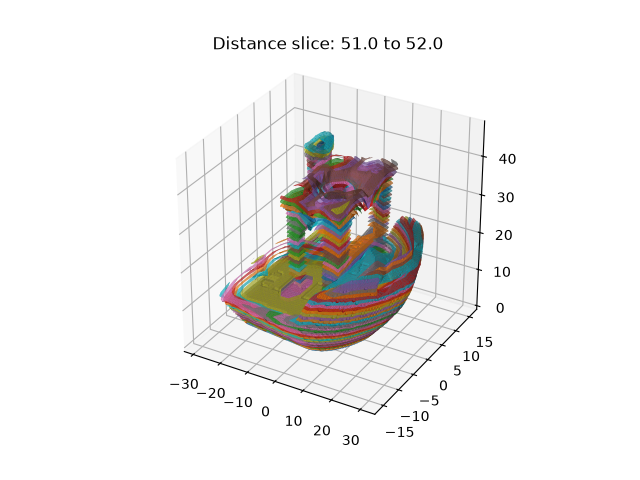

In [ ]:
print("plotting...")
# plot a 3d surface plot of the intersection points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
import matplotlib.tri as mtri

max_triangle_edge = 3.0  # Voxel-index units, like your splitting threshold

for layer_regions in slice_contours_corrected:
    for region in layer_regions:
        points = np.unique(np.asarray(region, dtype=float), axis=0)
        if len(points) < voxel_size * 3:
            continue
        try:
            triangulation = mtri.Triangulation(points[:, 0], points[:, 1])
        except (RuntimeError, ValueError):
            # XY projection may be degenerate for a vertical patch.
            ax.scatter(*points.T, s=1)
            continue
        triangles = points[triangulation.triangles]
        # Three physical edge lengths for every proposed triangle.
        edge_lengths = np.linalg.norm(triangles - np.roll(triangles, -1, axis=1), axis=2)

        reject = np.any(edge_lengths > max_triangle_edge, axis=1)

        if np.all(reject):
            ax.scatter(*points.T, s=1)
            continue

        triangulation.set_mask(reject)

        ax.plot_trisurf(
            triangulation,
            points[:, 2],
            linewidth=0.2,
            antialiased=True,
            alpha=1.0,
        )
ax.set_title(f"Distance slice: {dist} to {dist + dist_step}")
# set aspect ratio to be equal
ax.set_box_aspect([1, 1, 1])
plt.show()

# TODO:
- find something other than matplotlib or make rendering more efficient
- reconsider region splitting (at least dynamically based on voxel sizes) but make it more robust
- extend profiles to the edge of the mesh

# check grid vs sliced model

[[33.0, 41.0, 0.0], [36.0, 41.0, 0.0], [38.0, 43.0, 0.0], [41.0, 43.0, 0.0], [44.0, 43.0, 0.0], [46.0, 44.0, 0.0], [46.0, 46.0, 0.0], [47.0, 47.0, 0.0], [50.0, 47.0, 0.0], [52.0, 47.0, 0.0], [54.0, 46.0, 0.0], [55.0, 45.0, 0.0], [58.0, 45.0, 0.0], [61.0, 45.0, 0.0], [63.0, 46.0, 0.0], [66.0, 46.0, 0.0], [69.0, 46.0, 0.0], [70.0, 44.0, 0.0], [73.0, 44.0, 0.0], [75.0, 42.0, 0.0], [77.0, 42.0, 0.0], [79.0, 41.0, 0.0], [80.0, 39.0, 0.0], [80.0, 38.0, 0.0], [80.0, 35.0, 0.0], [83.0, 35.0, 0.0], [83.0, 37.0, 0.0], [84.0, 36.0, 0.0], [83.0, 36.0, 0.0], [84.0, 35.0, 0.0], [86.0, 33.0, 0.0], [86.0, 32.0, 0.0], [86.0, 29.0, 0.0], [84.0, 29.0, 0.0], [83.0, 31.0, 0.0], [82.0, 32.0, 0.0], [79.0, 32.0, 0.0], [79.0, 31.0, 0.0], [76.0, 31.0, 0.0], [75.0, 33.0, 0.0], [75.0, 35.0, 0.0], [77.0, 37.0, 0.0], [76.0, 39.0, 0.0], [74.0, 39.0, 0.0], [72.0, 41.0, 0.0], [71.0, 40.0, 0.0], [69.0, 39.0, 0.0], [68.0, 41.0, 0.0], [67.0, 43.0, 0.0], [65.0, 43.0, 0.0], [65.0, 40.0, 0.0], [63.0, 40.0, 0.0], [63.0, 37.0

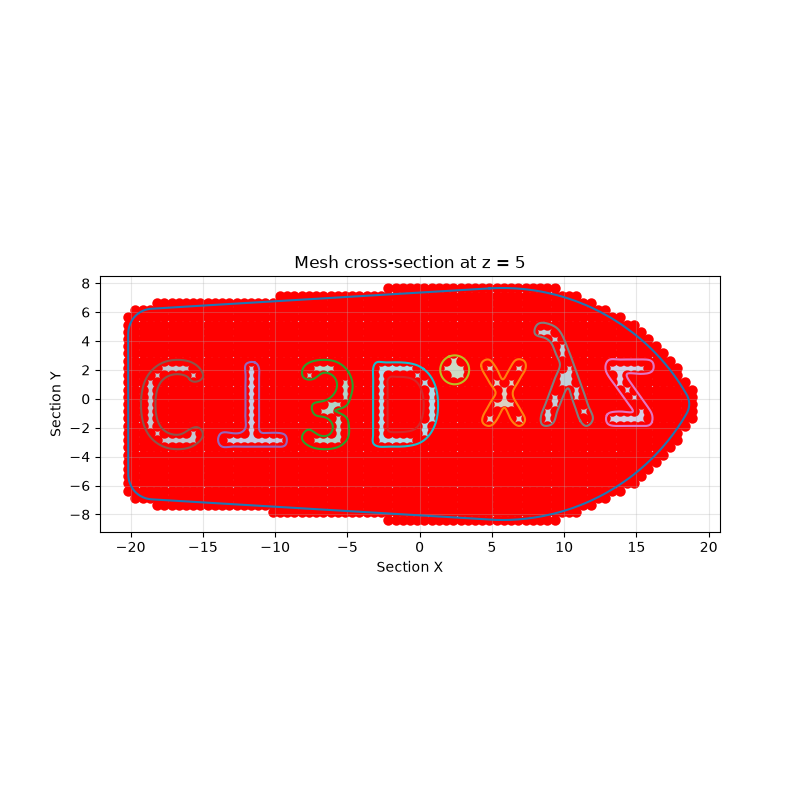

In [8]:
section = mesh.section(
    plane_origin=np.array([
        0.0,
        0.0,
        0,
    ]),
    plane_normal=np.array([
        0.0,
        0.0,
        1.0,
    ]),
)

slice_number = 0
print(slice_contours[slice_number][0])

# Project the 3D section into its local 2D plane and plot it with Matplotlib.
if section is None:
    print("The plane does not intersect the mesh.")
else:
    slice_2D, to_3D = section.to_2D()
    fig, ax = plt.subplots(figsize=(8, 8))

    for contour in slice_2D.discrete:
        contour = np.asarray(contour)
        ax.plot(contour[:, 0], contour[:, 1], linewidth=1.5)
        ax.fill(contour[:, 0], contour[:, 1], alpha=0.2)

    # project the first slice of slice_contours[0][0]
    first_slice = slice_contours[slice_number][0]

    # Voxel-index coordinates -> original mesh coordinates.
    points_world = trimesh.transform_points(np.asarray(first_slice, dtype=float), voxel_mesh.transform)

    # Original mesh coordinates -> the section's local coordinate system.
    points_section = trimesh.transform_points(points_world, np.linalg.inv(to_3D))

    # remove the z coordinate and plot the 2D projection
    first_slice_2D = points_section[:, :2]
    ax.scatter(first_slice_2D[:, 0], first_slice_2D[:, 1], linewidth=1.5, color='red')

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Section X")
    ax.set_ylabel("Section Y")
    ax.set_title("Mesh cross-section at z = 5")
    ax.grid(True, alpha=0.3)
    plt.show()